In [1]:
import os
os.chdir('../model_skingpt4')

In [2]:
import random
import numpy as np
import torch
import torch.backends.cudnn as cudnn
from PIL import Image

from skingpt4.common.config import Config
from skingpt4.common.dist_utils import get_rank
from skingpt4.common.registry import registry
from skingpt4.conversation.conversation import Chat, CONV_VISION

# imports modules for registration
from skingpt4.datasets.builders import *
from skingpt4.models import *
from skingpt4.processors import *
from skingpt4.runners import *
from skingpt4.tasks import *

/home/jq2uw/miniconda3/envs/skingpt4/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def setup_seeds(config):
    seed = config.run_cfg.seed + get_rank()
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    cudnn.benchmark = False
    cudnn.deterministic = True

# Initialize model with the correct config path
config_path = "eval_configs/skingpt4_eval_llama2_13bchat.yaml"  # llama
# config_path ='eval_configs/skingpt4_eval_vicuna.yaml' # vicuna
gpu_id = 0  # Update if using different GPU

# Create args object
class Args:
    def __init__(self):
        self.cfg_path = config_path
        self.gpu_id = gpu_id
        self.options = None

args = Args()
cfg = Config(args)

# Initialize model
print('Initializing Chat')
model_config = cfg.model_cfg
model_config.device_8bit = args.gpu_id
model_cls = registry.get_model_class(model_config.arch)
model = model_cls.from_config(model_config).to('cuda:{}'.format(args.gpu_id))

vis_processor_cfg = cfg.datasets_cfg.cc_sbu_align.vis_processor.train
vis_processor = registry.get_processor_class(vis_processor_cfg.name).from_config(vis_processor_cfg)
chat = Chat(model, vis_processor, device='cuda:{}'.format(args.gpu_id))
print('Initialization Finished')

Initializing Chat
Loading VIT


/home/jq2uw/miniconda3/envs/skingpt4/lib/python3.9/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading VIT Done
Loading Q-Former
Loading Q-Former Done
Loading LLM tokenizer
Loading LLM model


Loading checkpoint shards: 100%|██████████| 3/3 [00:09<00:00,  3.14s/it]


Loading LLM Done
Load 2 training prompts
Prompt Example 
###Human: <Img><ImageHere></Img> Could you describe the skin disease in this image for me? ###Assistant: 
Load BLIP2-LLM Checkpoint: /scratch/jq2uw/edit-skingpt4/model_skingpt4/weights/skingpt4_llama2_13bchat_finetune_v4.2_small_class.pth
Initialization Finished


In [4]:
def chat_with_image(image, question, num_beams=1, temperature=1.0):
    # Initialize conversation
    chat_state = CONV_VISION.copy()
    img_list = []
    llm_message = chat.upload_img(image, chat_state, img_list)
    chat.ask(question, chat_state)
    response = chat.answer(
        conv=chat_state,
        img_list=img_list,
        num_beams=num_beams,
        temperature=temperature,
        max_new_tokens=300,
        max_length=2000
    )[0]
    return response

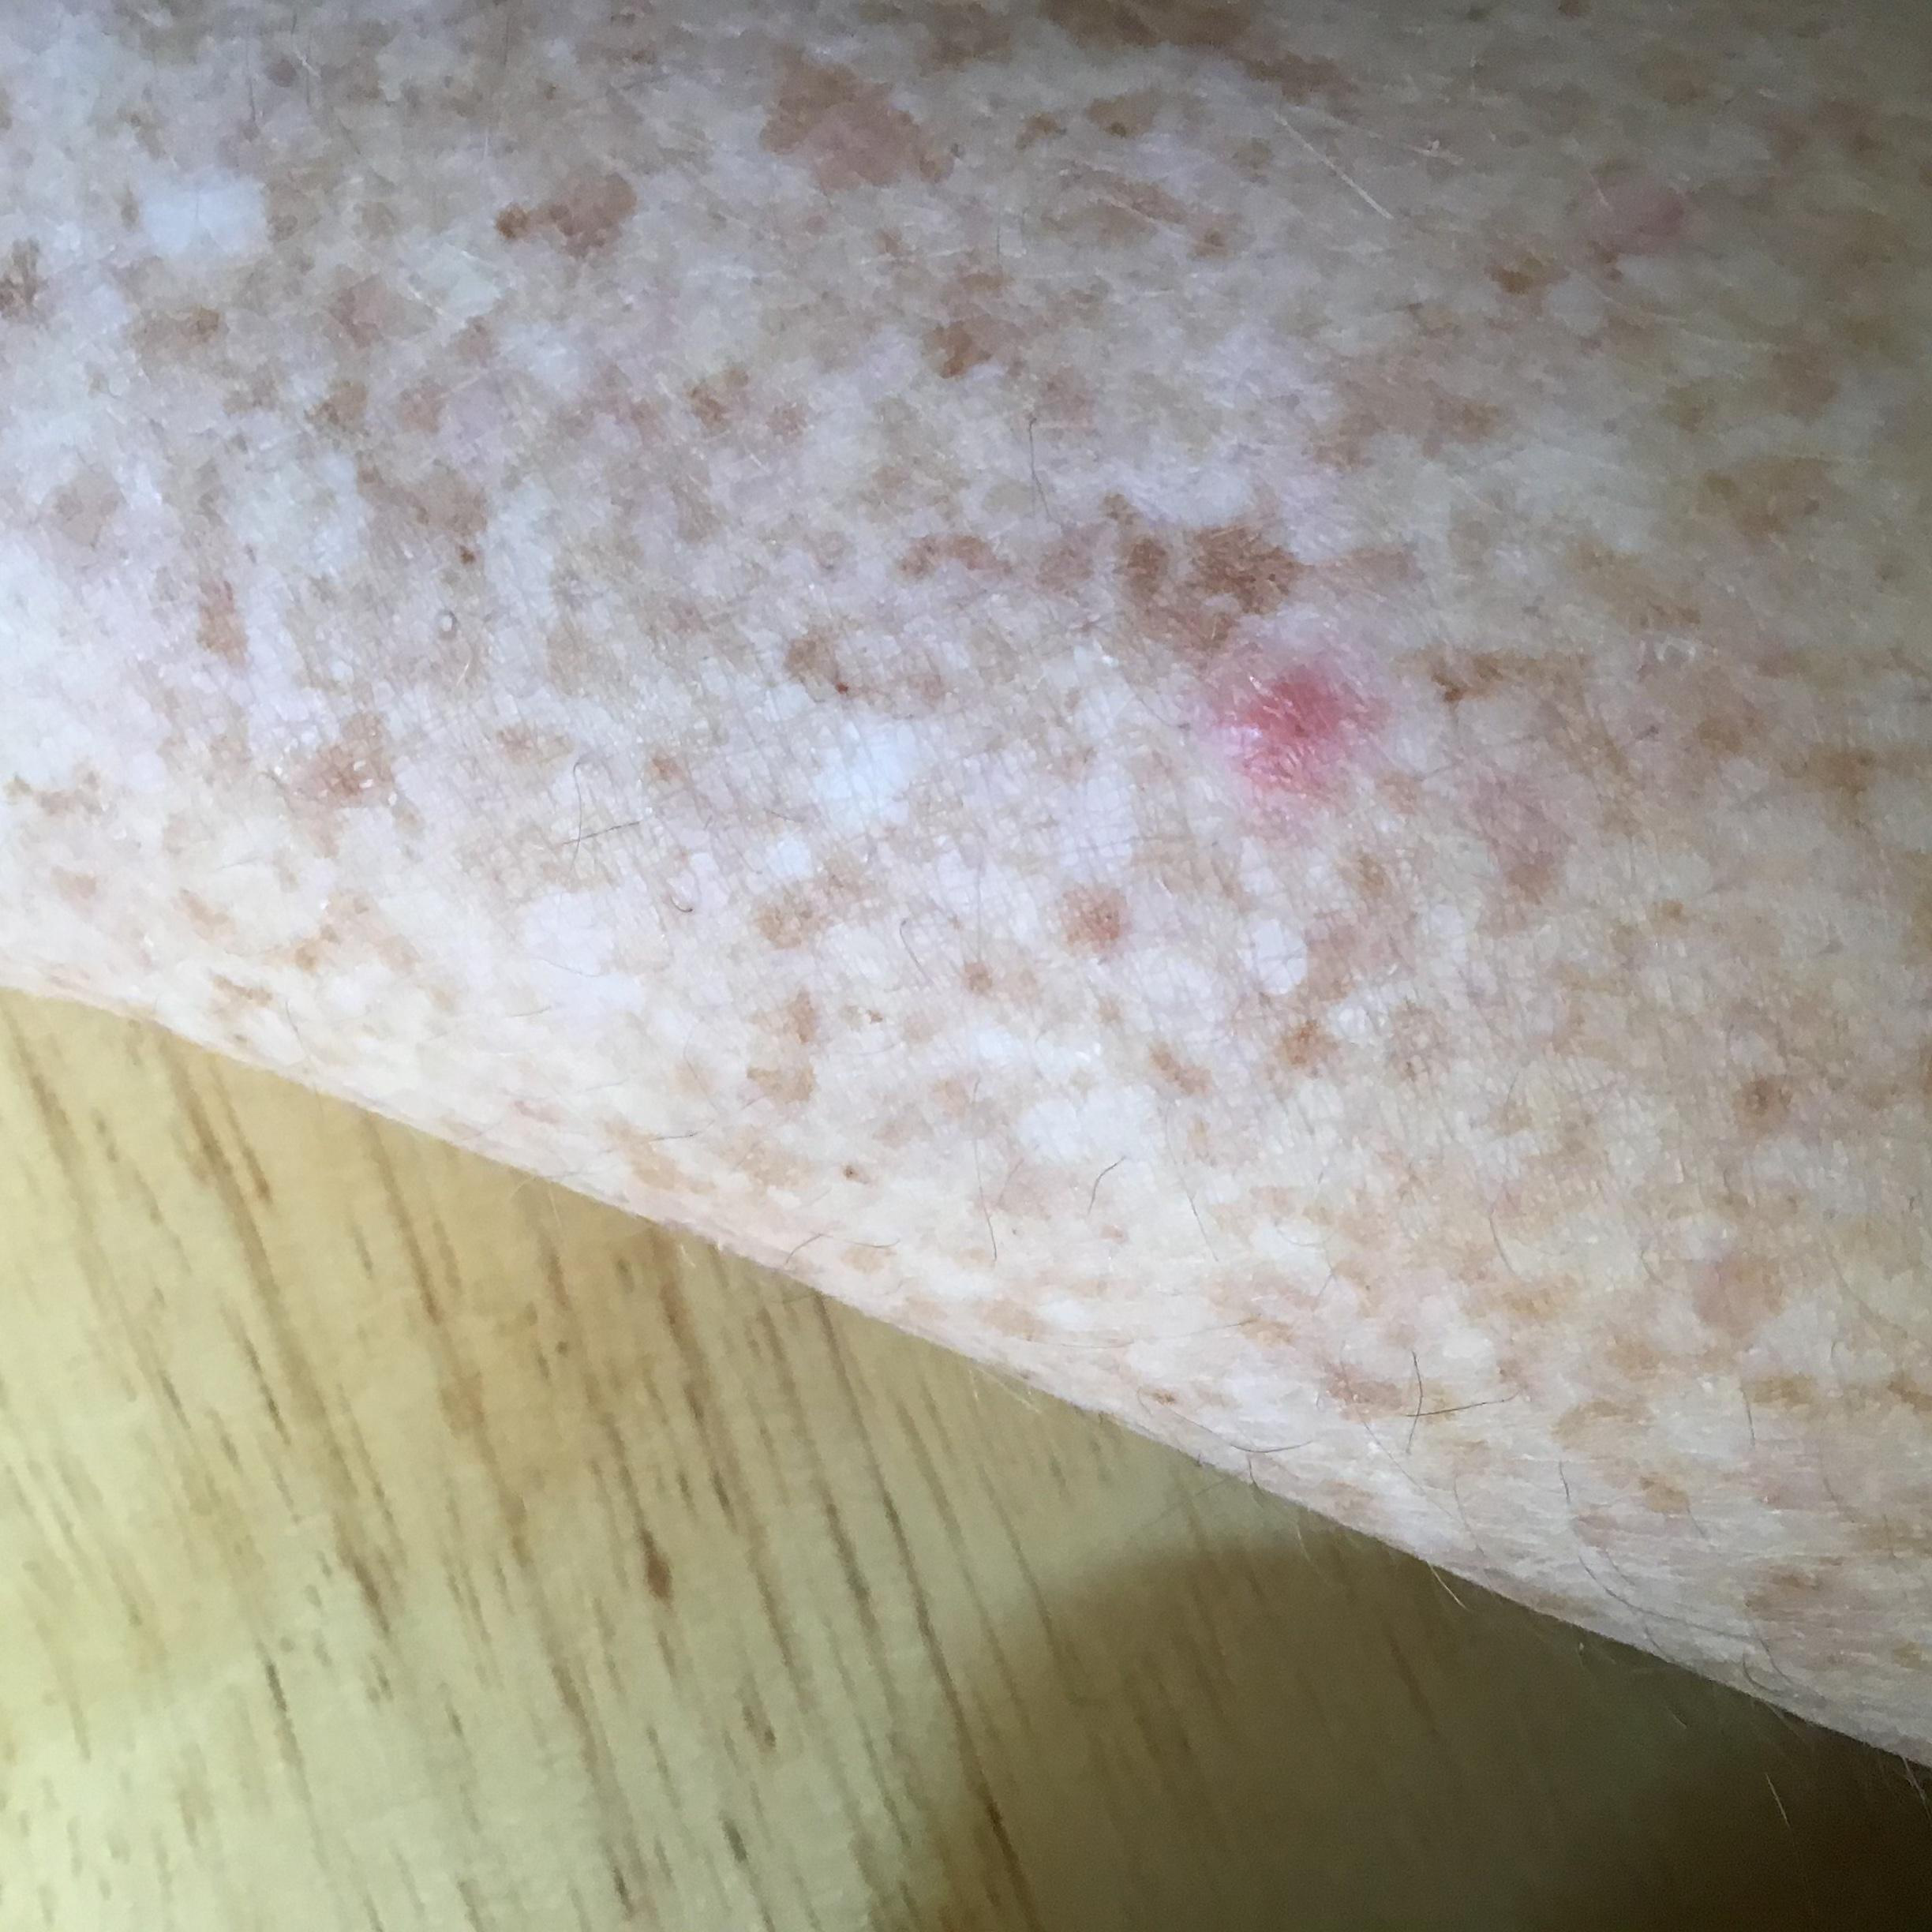

--------------------------------------------------

Q: What do you see in this skin image?
--------------------------------------------------
A: The image shows a close up view of a person's arm, with skin that appears to be red and inflamed. There are small bumps and redness on the skin, as well as some scabbing or peeling on the surface. The image is slightly blurry, making it difficult to see precise details.
--------------------------------------------------

Q: Are there any concerning features?
--------------------------------------------------
A: The image shows a person's arm with a small red bump on the wrist. The skin appears smooth and unbroken, with no signs of irritation or infection. The bump itself is small and round, with a small amount of redness around it. There are no visible signs of infection or inflammation in the surrounding skin.
--------------------------------------------------

Q: What would you recommend regarding this skin condition?
-----------------------

In [6]:
from IPython.display import display
import matplotlib.pyplot as plt

# Load and display image
image = Image.open("../data/s-prd-396524710.jpg")  # Update this path
display(image)

# Ask questions about the image
questions = [
    "What do you see in this skin image?",
    "Are there any concerning features?",
    "What would you recommend regarding this skin condition?"
]

for question in questions:
    response = chat_with_image(image, question)
    print("-" * 50)
    print(f"\nQ: {question}")
    print("-" * 50)
    print(f"A: {response}")